# Feature selection

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
### Standard imports
import copy
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

In [3]:
### Specific imports
import optuna
import torch
import torchmetrics
from torch.utils.data import DataLoader, TensorDataset

/home/oskar/anaconda3/envs/brd4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Jupyter Settings

In [4]:
### Random seed - using the same seed for robustness
SEED = 42
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames

In [5]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
from similarity_sali import MorganSimilarity

# Data
To ensure reproducibility `01_brd4_inhibitors_2k.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

2920


,ID,Mol,pIC50,active
0,CHEMBL1097107,,6.25,NaN
1,CHEMBL1232461,,7.01,1.00
2,CHEMBL1233528,,6.92,1.00

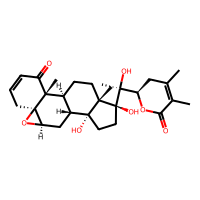
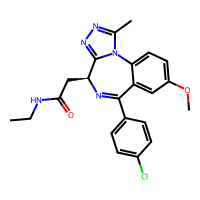
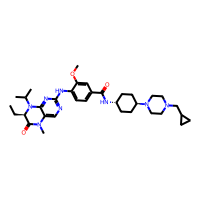

In [6]:
df = pd.read_pickle("../data/01_brd4_all_inhibitors.pkl")
print(len(df))
render_mol(df.head(3))

## Morgan fingerprints

From the [SALI analysis](../01_eda/02_activity_cliffs.ipynb) we know that `radius = 3` is important for this data set and `nBits = 512` is chosen. 

The method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()` is used to calculate the fingerprints. 

In [7]:
### Number of Morgan fingerprints (features)
n_bits = 512

### Instantiate the class
morgan = MorganSimilarity(df, radius=3, nBits=n_bits, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("DataFrame")

morgan.fp

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0,1,0,0,0,1,0,0,1,0,...,0,0,0,0,1,1,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
3,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,1,0,0,0,1
2916,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2917,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2918,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Data Split
To reduce computational cost a validation set is generated in a addition to training and test ses rather than performing cross-validation. Equal activity distribution is ensured by binning and stratified sampling.   

In [8]:
### Create bins for stratification
df["bins"] = pd.qcut(df["pIC50"], q=10, labels=False)

### Generate the training set
X_train, X_temp, y_train, y_temp = sk.model_selection.train_test_split(
    morgan.fp,
    df["pIC50"],
    test_size=0.3,
    random_state=SEED,
    stratify=df["bins"],
)

### Generate the validation and test sets
X_val, X_test, y_val, y_test = sk.model_selection.train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=df.loc[y_temp.index, "bins"],
)

In [9]:
print("train.shapes:", X_train.shape, y_train.shape)
print("val.shapes:", X_val.shape, y_val.shape)
print("test.shapes:", X_test.shape, y_test.shape)

train.shapes: (2044, 512) (2044,)
val.shapes: (438, 512) (438,)
test.shapes: (438, 512) (438,)


## Data Loader
The datasets converted to the native format of PyTorch. The `batch_size` is a tunable hyperparameter.  

In [10]:
def df_to_dataloader(X, y, batch_size=32, shuffle=True):
    """
    Convert a pandas DataFrame to a PyTorch DataLoader.

    Parameters
    ----------
    X : pandas.DataFrame
        Features
    y : pandas.Series
        Target
    batch_size : int
        Number of samples per batch
    shuffle : bool
        Shuffle the data
    
    Returns
    -------
    DataLoader
    """
    dataset = TensorDataset(
        torch.tensor(X.to_numpy(), dtype=torch.float32).to(device),
        torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1).to(device),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [11]:
### Use GPU if available
device = "cuda:3" if torch.cuda.is_available() else "cpu"

### PyTorch DataLoaders
train_loader = df_to_dataloader(X_train, y_train, batch_size=32, shuffle=True)
val_loader = df_to_dataloader(X_val, y_val, batch_size=32, shuffle=False)
test_loader = df_to_dataloader(X_test, y_test, batch_size=32, shuffle=False)

# Model Architecture
A network with two hidden layers and adjustable layer width (n_hidden). 

In [12]:
### Define the model architecture
class Net(torch.nn.Module):
    def __init__(self, n_features, n_hidden1, n_hidden2):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(n_features, n_hidden1)
        self.fc2 = torch.nn.Linear(n_hidden1, n_hidden2)
        self.fc3 = torch.nn.Linear(n_hidden2, 1)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## Training Loop

In [13]:
def training_loop(
    n_epochs,
    eval_interval,
    model,
    optimizer,
    train_loader=test_loader,
    test_loader=test_loader,
    plot=True,
):
    """
    Training loop with evaluation for a PyTorch model

    Parameters
    ----------
    n_epochs : int
        Number of epochs to train the model
    eval_interval : int
        Interval to evaluate the model
    model : torch.nn.Module
        PyTorch model to train
    optimizer : torch.optim.Optimizer
        PyTorch optimizer to use
    train_loader : torch.utils.data.DataLoader
        DataLoader for the training set
    test_loader : torch.utils.data.DataLoader
        DataLoader for the test set
    plot : bool
        Whether to plot the train and test errors
    
    Returns
    -------
    error_df : pd.DataFrame
        DataFrame with the train loss and test error
    """

    ### Set the network to training mode
    model.train()

    ### Define the loss function
    criterion = torch.nn.MSELoss()

    ### Initialize the error metric
    rmse = torchmetrics.regression.MeanSquaredError().to(device)

    ### DataFrame to store the train loss and test error
    error_df = pd.DataFrame(
        {
            "epoch": range(n_epochs),
            "train_loss": np.nan,
            "test_error": np.nan,
        }
    ).set_index("epoch")

    ### Training loop
    for epoch in tqdm(range(n_epochs)):
        ### Initialize running loss
        running_loss = 0.0

        ### Loop over the DataLoader
        for batch_X, batch_Y in train_loader:
            ### Move the data to the appropriate device
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

            ### Set the parameter gradients to zero
            optimizer.zero_grad()

            ### Forward the training data through the model cnn
            output = model(batch_X)

            ### Compute the loss
            loss = criterion(output, batch_Y)

            ### Add the loss to the running loss
            running_loss += loss.item()

            ### Compute the gradients by applying a backward() step to the calculated loss
            loss.backward()

            ### Perform an optimization step by applying step() to your optimizer
            optimizer.step()

        ### Save the training loss
        error_df.loc[epoch, "train_loss"] = running_loss / len(train_loader)

        ### Calculate the test error every eval_interval epochs
        if epoch % eval_interval == 0 or epoch == n_epochs - 1:
            ### Set the model in evaluation
            model.eval()

            ### Disable gradient computation
            with torch.no_grad():
                ### Loop over the DataLoader
                for batch_X, batch_Y in test_loader:
                    ### Move the data to the appropriate device
                    batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

                    ### Forward the training data through the model cnn
                    output = model(batch_X)

                    ### Compute the accuracy
                    rmse.update(output, batch_Y)

            ### Compute the test error
            error_df.loc[epoch, "test_error"] = rmse.compute().item()
            rmse.reset()

    ### Convert MSEs to RMSEs for interpretation
    error_df["train_loss"] = np.sqrt(error_df["train_loss"])
    error_df["test_error"] = np.sqrt(error_df["test_error"])

    ### Plot the train and test accuracy
    if plot:
        ### Train
        sns.scatterplot(data=error_df, x="epoch", y="train_loss", label="Train Error")

        ### Test
        sns.scatterplot(data=error_df, x="epoch", y="test_error", label="Test Error")

        ### Formatting
        plt.xlabel("Epoch")
        plt.ylabel("RMSE")
        plt.legend()
        plt.title("Train and Test RMSE")
        plt.show()

    return error_df

# Overfitting
Initially the training data is overfitted to demonstrate that the problem (predicting pIC50 values from Morgan fingerprints) is solvable. This is achieved as the test error from the validation set plateaus while the training error still decreases. 100 epochs will be used for hyperparameter-tuning. 

100%|██████████| 300/300 [00:14<00:00, 20.41it/s]


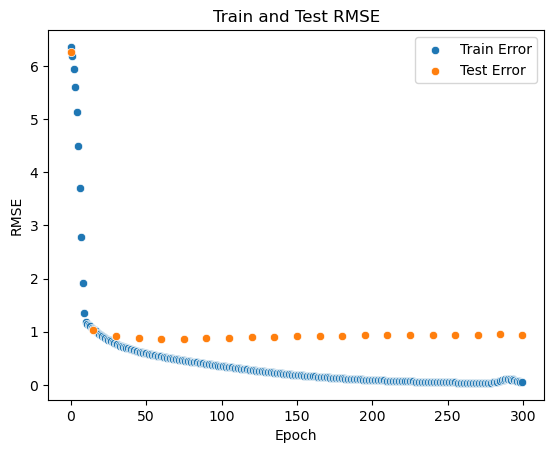

In [14]:
### Instantiate the model
net = Net(
    n_features=n_bits,  # Number of features (Morgan fingerprints)
    n_hidden1=128,  # Number of neurons in the first hidden layer
    n_hidden2=64,  # Number of neurons in the second hidden layer
).to(device)  # Create the network and send it to the device

### Define the optimizer
optim = torch.optim.Adam(
    net.parameters(),  # Parameters to optimize
    lr=1e-4,  # Learning rate
    weight_decay=0,  # L2/Ridge regularization
)

### Training loop
error_df = training_loop(
    model=net,
    optimizer=optim,
    n_epochs=300,
    eval_interval=15,
    test_loader=val_loader,
    plot=True,
)

# Hyperparameter-tuning

In [15]:
def objective(trial):
    """
    Objective function for Bayesian Optimization
    """
    
    # Sample hyperparameters
    n_hidden1 = trial.suggest_categorical('n_hidden1', [32, 64, 128])
    n_hidden2 = trial.suggest_categorical('n_hidden2', [16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # Instantiate model
    net = Net(
        n_features=n_bits,
        n_hidden1=n_hidden1,
        n_hidden2=n_hidden2,
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    # DataLoader with tuned batch size
    train_loader = df_to_dataloader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = df_to_dataloader(X_val, y_val, batch_size=batch_size, shuffle=False)

    ### Train the model
    error_df = training_loop(
        model=net,
        optimizer=optimizer,
        n_epochs=50,                    # Fixed as per your earlier decision
        eval_interval=50,               # Less frequent evaluation for faster tuning
        test_loader=val_loader,
        train_loader=train_loader,
        plot=False,
    )

    ### Return the final test RMSE for evaluation
    return error_df['test_error'].iloc[-1]


In [19]:
### Create the study
study = optuna.create_study(direction='minimize')  # Minimize RMSE

# Run optimization
study.optimize(objective, n_trials=100)

# Display best results
print("Best hyperparameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2025-03-23 17:05:29,445] A new study created in memory with name: no-name-9e569a2d-d245-4890-a508-808750b57ce0
100%|██████████| 50/50 [00:06<00:00,  8.06it/s]
[I 2025-03-23 17:05:35,739] Trial 0 finished with value: 0.837875579485493 and parameters: {'n_hidden1': 64, 'n_hidden2': 16, 'learning_rate': 0.00011381262295783205, 'weight_decay': 0.0006296271518208081, 'batch_size': 64}. Best is trial 0 with value: 0.837875579485493.
100%|██████████| 50/50 [00:17<00:00,  2.82it/s]
[I 2025-03-23 17:05:53,507] Trial 1 finished with value: 0.7373600212705935 and parameters: {'n_hidden1': 64, 'n_hidden2': 16, 'learning_rate': 0.00025584208780583036, 'weight_decay': 0.0003733790137025675, 'batch_size': 16}. Best is trial 1 with value: 0.7373600212705935.
100%|██████████| 50/50 [00:06<00:00,  7.80it/s]
[I 2025-03-23 17:05:59,936] Trial 2 finished with value: 1.0054491706607598 and parameters: {'n_hidden1': 64, 'n_hidden2': 16, 'learning_rate': 3.710589392532887e-05, 'weight_decay': 0.00043028333

Best hyperparameters: {'n_hidden1': 128, 'n_hidden2': 64, 'learning_rate': 0.000919739947373432, 'weight_decay': 0.0008907058065102718, 'batch_size': 16}
Best RMSE: 0.6331566004572573


In [20]:
optuna.visualization.plot_optimization_history(study)


In [21]:
optuna.visualization.plot_param_importances(study)
